In [2]:
import pandas as pd
offers = pd.read_csv("datasets/data_offers.csv")
orders = pd.read_csv("datasets/data_orders.csv")

In [3]:
#1st dataset
orders.shape

(10716, 8)

In [4]:
orders.sample(n=10, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
10309,0:29:14,-0.966062,51.454821,NaN,3000555146103,4,0,44.0
6705,1:28:45,-0.970472,51.456725,NaN,3000595870644,4,0,121.0
304,8:22:36,-0.916708,51.439852,NaN,3000627783633,9,0,NaN
9143,7:32:27,-0.955580,51.453493,1078.0,3000622140805,4,1,1017.0
10593,4:39:55,-0.946358,51.439779,NaN,3000554645524,4,0,121.0
8654,8:05:02,-0.967327,51.449395,598.0,3000592772077,4,1,48.0
3919,0:21:47,-0.971597,51.457574,NaN,3000624492441,4,0,180.0
4337,20:26:40,-0.971296,51.458115,NaN,3000628755869,4,0,104.0
6931,7:25:39,-0.942301,51.474812,NaN,3000628430595,4,0,44.0
967,13:41:31,-0.952194,51.444067,NaN,3000623591189,9,0,NaN


In [5]:
#2nd dataset
offers.shape

(334363, 2)

In [6]:
offers.sample(n=10, random_state=42)

,order_gk,offer_id
244971,3000627481054,300052086404
236783,3000631282042,300052342376
22714,3000624367715,300051909011
306983,3000557436646,300050769980
170256,3000588131807,300051201442
316173,3000629756224,300052250019
234398,3000625018320,300051967737
122107,3000629082264,300052196687
60909,3000588606991,300051225443
52998,3000629981908,300052274857


In [7]:
#Merging both datasets for easier data manipulation
df = orders.merge(right=offers, how="inner", on="order_gk")

In [8]:
df.sample(n=10, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,4,1,223.0,300050725946
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,4,0,91.0,300052014519
29083,9:16:38,-1.033560,51.441967,NaN,3000594099225,4,0,68.0,300051458740
16926,2:08:09,-0.967676,51.444489,NaN,3000626980467,4,0,125.0,300052031394
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,4,0,11.0,300050671163
13008,3:03:45,-0.966745,51.453236,NaN,3000593295623,9,0,NaN,300051413313
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,4,0,6.0,300051090742
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,9,0,NaN,300051125957
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,4,0,113.0,300052078801
18189,7:52:29,-0.973793,51.458665,479.0,3000587781360,4,1,47.0,300051178628


In [9]:
#Data cleaning for easy understanding

In [10]:
import numpy as np

df["is_driver_assigned"] = np.where(df["is_driver_assigned_key"] == 1, "Yes", "No")
df["order_status"] = np.where(df["order_status_key"] == 4, "Client Cancelled", "System Reject")

df.drop(columns=["is_driver_assigned_key", "order_status_key"], inplace=True)

In [11]:
df.sample(n=10, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,223.0,300050725946,Yes,Client Cancelled
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,91.0,300052014519,No,Client Cancelled
29083,9:16:38,-1.033560,51.441967,NaN,3000594099225,68.0,300051458740,No,Client Cancelled
16926,2:08:09,-0.967676,51.444489,NaN,3000626980467,125.0,300052031394,No,Client Cancelled
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,11.0,300050671163,No,Client Cancelled
13008,3:03:45,-0.966745,51.453236,NaN,3000593295623,NaN,300051413313,No,System Reject
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,6.0,300051090742,No,Client Cancelled
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,NaN,300051125957,No,System Reject
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,113.0,300052078801,No,Client Cancelled
18189,7:52:29,-0.973793,51.458665,479.0,3000587781360,47.0,300051178628,Yes,Client Cancelled


In [12]:
#Assignment 1

In [13]:
df.groupby(by=["is_driver_assigned", "order_status"])["order_gk"].count()

is_driver_assigned  order_status    
No                  Client Cancelled    13435
                    System Reject        9469
Yes                 Client Cancelled     8360
                    System Reject           4
Name: order_gk, dtype: int64

<Axes: >

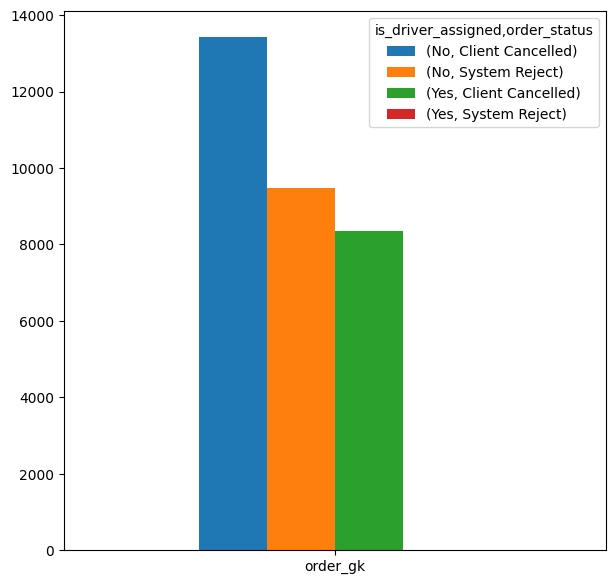

In [25]:
df_task1 = df.pivot_table(columns=["is_driver_assigned", "order_status"], values="order_gk", aggfunc="count")
df_task1.plot(kind="bar", subplots=False, figsize=(7, 7), legend=True, rot=0)

In [15]:
#Task 2

In [16]:
df

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,198.0,300050983403,Yes,Client Cancelled
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986179,No,Client Cancelled
2,20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986174,No,Client Cancelled
3,20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986180,No,Client Cancelled
4,12:07:50,-0.969520,51.455544,477.0,3000582891479,46.0,300050976275,Yes,Client Cancelled
...,...,...,...,...,...,...,...,...,...
31263,12:44:11,-0.975372,51.457846,NaN,3000597886155,43.0,300051590196,No,Client Cancelled
31264,12:42:52,-0.975372,51.457846,NaN,3000597886140,44.0,300051590176,No,Client Cancelled
31265,13:11:35,-0.975372,51.457846,NaN,3000599186906,36.0,300051648809,No,Client Cancelled
31266,13:17:21,-0.972926,51.457693,60.0,3000599187034,34.0,300051648910,Yes,Client Cancelled


In [17]:
# extracting hour from the time column
df["order_hour"] = df["order_datetime"].str.split(":").apply(lambda split: split[0])

In [18]:
# checking that the transformation is correct
df.sample(n=5, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status,order_hour
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,223.0,300050725946,Yes,Client Cancelled,21
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,91.0,300052014519,No,Client Cancelled,10
29083,9:16:38,-1.033560,51.441967,NaN,3000594099225,68.0,300051458740,No,Client Cancelled,9
16926,2:08:09,-0.967676,51.444489,NaN,3000626980467,125.0,300052031394,No,Client Cancelled,2
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,11.0,300050671163,No,Client Cancelled,21


<Axes: title={'center': 'Count of Failed Orders by Hour of Day'}, xlabel='order_hour'>

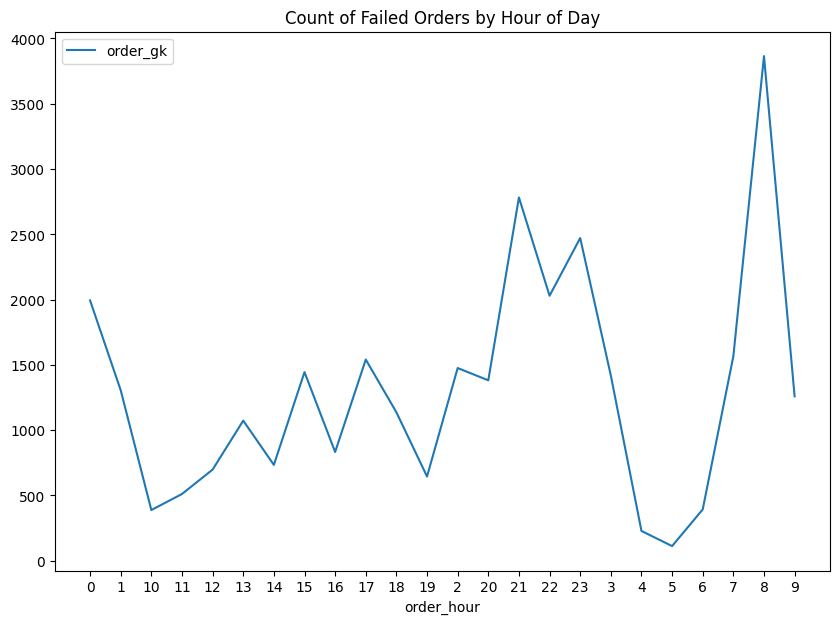

In [19]:
df.groupby(by="order_hour")["order_gk"].count().plot(figsize=(10, 7),legend=True,xticks=range(0, 24),title="Count of Failed Orders by Hour of Day")

In [26]:
grouped_task2 = df.groupby(by=["order_hour", "is_driver_assigned", "order_status"])["order_gk"].count()
grouped_task2

order_hour  is_driver_assigned  order_status    
0           No                  Client Cancelled     957
                                System Reject        706
            Yes                 Client Cancelled     326
                                System Reject          4
1           No                  Client Cancelled     633
                                                    ... 
8           No                  System Reject       1338
            Yes                 Client Cancelled    1080
9           No                  Client Cancelled     470
                                System Reject        294
            Yes                 Client Cancelled     494
Name: order_gk, Length: 73, dtype: int64

<Axes: title={'center': 'Count of Failed Orders Per Hour and Category'}, xlabel='order_hour'>

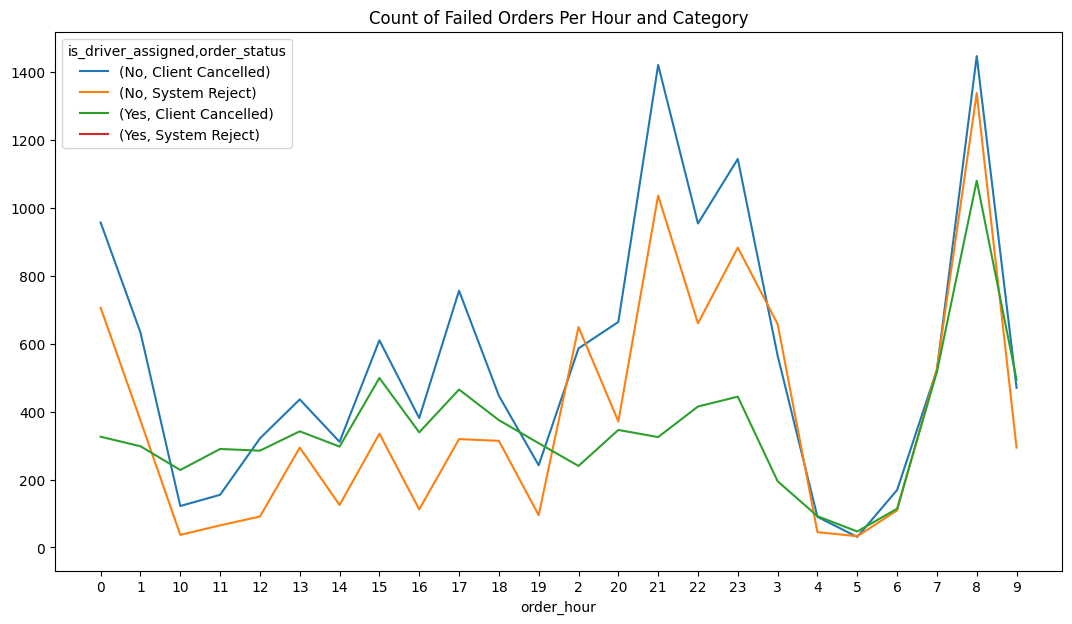

In [27]:
grouped_task2.reset_index().pivot(index="order_hour",
                                   columns=["is_driver_assigned", "order_status"],
                                   values="order_gk").plot(xticks=range(0, 24),
                                   figsize=(13, 7),
                                   title="Count of Failed Orders Per Hour and Category")

In [22]:
#Task 3

In [23]:
grouped_task3 = df.groupby(by=["order_hour", "is_driver_assigned"])["cancellations_time_in_seconds"].mean()
grouped_q3

order_hour  is_driver_assigned
0           No                    115.126437
            Yes                   276.082822
1           No                    100.593997
            Yes                   296.312081
10          No                     93.795082
            Yes                   206.447368
11          No                     93.090323
            Yes                   276.793103
12          No                    128.224299
            Yes                   243.000000
13          No                    103.577982
            Yes                   248.301170
14          No                    112.752412
            Yes                   241.367003
15          No                    140.970492
            Yes                   188.380762
16          No                    123.181102
            Yes                   217.126844
17          No                    106.842593
            Yes                   280.782796
18          No                     85.845638
            Yes         

<Axes: title={'center': 'Average Time to Cancellation Per Hour and Driver Assignment'}, xlabel='order_hour'>

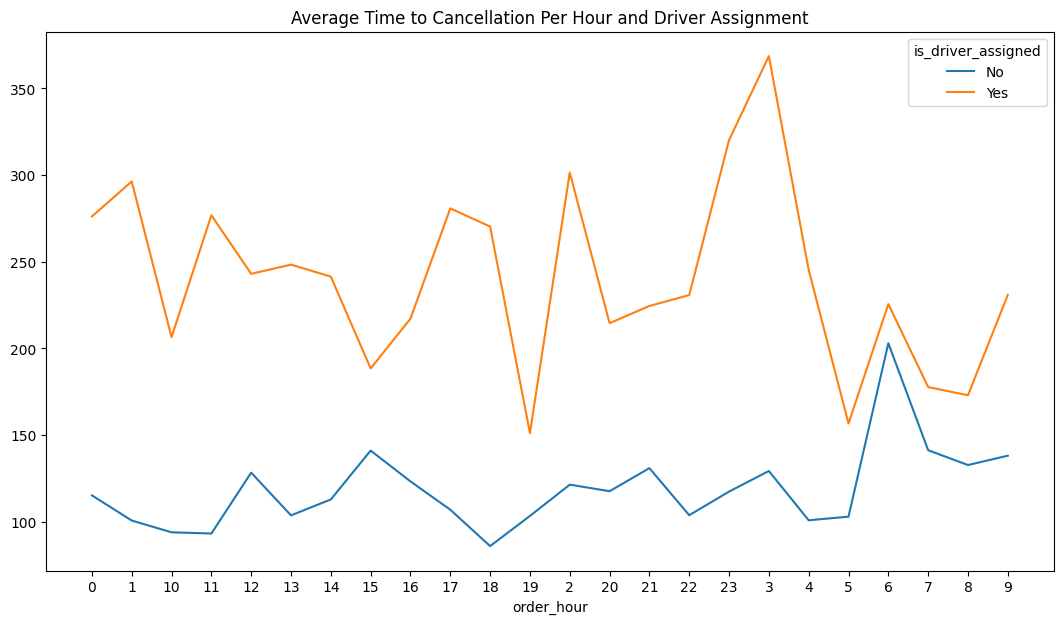

In [24]:
grouped_q3.reset_index().pivot(index="order_hour",
                                   columns="is_driver_assigned",
                                   values="cancellations_time_in_seconds").plot(xticks=range(0, 24),
                                   figsize=(13, 7),
                                   title="Average Time to Cancellation Per Hour and Driver Assignment")